# **DATA EXPLORATION**

---

## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import sys
import os

## **2. Load Raw Data**

Trong giai đoạn đầu của quá trình khám phá dữ liệu (EDA), chúng em tiến hành tải dữ liệu thô (raw data) từ tệp CSV được lưu trữ trong cấu trúc thư mục dự án (`data/raw`).

In [2]:
energy_path = "../../data/raw/Energy_Use.csv"
df_energy = pd.read_csv(energy_path)

Dữ liệu được đọc từ tệp `Energy_Use.csv` và được khởi tạo dưới dạng cấu trúc bảng lưu vào biến DataFrame `df_energy`.

## **3. Basic Dataset Overview**

### **3.1 Dataset Dimensions**

Bước đầu tiên để nắm bắt quy mô của dữ liệu là kiểm tra chiều không gian (số lượng quan sát và số lượng đặc trưng).

In [3]:
num_rows_energy, num_cols_energy = df_energy.shape
print(f"Number of rows: {num_rows_energy}")
print(f"Number of columns: {num_cols_energy}")

Number of rows: 19735
Number of columns: 29


Bộ dữ liệu **Appliances Energy Prediction** bao gồm *19.735 quan sát* và *29 biến đặc trưng*. Cụ thể, không gian đặc trưng bao gồm 27 biến liên tục (đo lường nhiệt độ, độ ẩm trong nhà/ngoài trời, và các thông số thời tiết khác), 1 biến thời gian (`date`) và 1 biến mục tiêu (`Appliances` - lượng điện năng tiêu thụ). Quy mô và sự đa dạng của các biến số này cung cấp một nền tảng vững chắc để thực hiện các phân tích tương quan đa biến và xây dựng các mô hình Hồi quy (Regression) dự báo mức tiêu thụ năng lượng.

### **3.2 Observational Unit**

Đơn vị quan sát cốt lõi của tập dữ liệu này được xác định như sau:

> **Một bản ghi tương ứng với một chu kỳ đo lường tổng hợp kéo dài 10 phút tại một ngôi nhà duy nhất.**

**Đặc điểm cấu trúc dữ liệu:**
Khác với cấu trúc panel-like data ở nhiều địa điểm, bộ dữ liệu này thuần túy mang cấu trúc *Time-series* tần suất cao. Các tín hiệu từ mạng lưới cảm biến không dây ZigBee trong nhà (thu thập mỗi 3.3 phút) và dữ liệu thời tiết thực tế từ trạm khí tượng đã được đồng bộ hóa và tính trung bình theo chu kỳ 10 phút liên tục trong suốt 4.5 tháng.

### **3.3 Initial Data Glimpse**

Để có cái nhìn ban đầu về cấu trúc và đặc điểm của dataset, chúng em hiển thị một số dòng đầu và cuối để kiểm tra định dạng dữ liệu và mức độ nhất quán:

In [4]:
# Xem 5 dòng đầu
df_energy.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,11-01-2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,11-01-2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,11-01-2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,11-01-2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,11-01-2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [5]:
# Xem 5 dòng cuối
df_energy.tail()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
19730,27-05-2016 17:20,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.7,...,23.2,46.7900,22.7,755.2,55.666667,3.333333,23.666667,13.3,43.096812,43.096812
19731,27-05-2016 17:30,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.7,...,23.2,46.7900,22.6,755.2,56.000000,3.500000,24.500000,13.3,49.282940,49.282940
19732,27-05-2016 17:40,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.7,...,23.2,46.7900,22.5,755.2,56.333333,3.666667,25.333333,13.3,29.199117,29.199117
19733,27-05-2016 17:50,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.7,...,23.2,46.8175,22.3,755.2,56.666667,3.833333,26.166667,13.2,6.322784,6.322784
19734,27-05-2016 18:00,430,10,25.500000,46.600000,25.264286,42.971429,26.823333,41.156667,24.7,...,23.2,46.8450,22.2,755.2,57.000000,4.000000,27.000000,13.2,34.118851,34.118851


**Summary of Column Types**

In [6]:
df_energy.dtypes.value_counts()

float64    26
int64       2
object      1
Name: count, dtype: int64

Kết quả phân tích kiểu dữ liệu cho thấy tập dữ liệu `df_energy` cực kỳ lý tưởng cho các bài toán Học máy định lượng. Có tới 28/29 thuộc tính mang kiểu dữ liệu số (`float64` và `int64`), đại diện cho các thông số đo lường vật lý liên tục từ cảm biến (nhiệt độ, độ ẩm, áp suất, tốc độ gió) và mức tiêu thụ điện năng.

Biến duy nhất có kiểu `object` (chuỗi ký tự) là cột `date`. Từ góc độ tiền xử lý, định dạng chuỗi của cột này chưa thể sử dụng trực tiếp cho các phép toán chuỗi thời gian, do đó yêu cầu bắt buộc là phải ép kiểu (type-casting) cột này về định dạng `datetime` chuẩn của Pandas trước khi tiến hành phân tích sâu hơn.

### **3.4 Temporal Coverage & Spatial Distribution**

In [7]:
df_energy['date'] = pd.to_datetime(df_energy['date'], format='%d-%m-%Y %H:%M')
print(df_energy['date'].min(), "đến", df_energy['date'].max())

2016-01-11 17:00:00 đến 2016-05-27 18:00:00


**Temporal Coverage:** Dữ liệu trải dài liên tục từ chiều ngày `11/01/2016` đến chiều ngày `27/05/2016` (khoảng 4.5 tháng). Tần suất lấy mẫu dày đặc (mỗi 10 phút/lần) tạo ra một chuỗi thời gian có độ phân giải cao (high-resolution time-series), rất phù hợp để bắt được các chu kỳ sử dụng điện năng ngắn hạn (theo giờ trong ngày) và trung hạn (theo ngày trong tuần).

**Spatial Distribution:** Khác với bộ dữ liệu khí tượng diện rộng, toàn bộ tập dữ liệu này được thu thập tại một địa điểm duy nhất (một ngôi nhà tiết kiệm năng lượng tại Bỉ). Sự cố định về mặt không gian này loại bỏ được nhiễu loạn do sai biệt địa lý, giúp mô hình tập trung hoàn toàn vào việc học các quy luật nhiệt động lực học trong nhà và tác động của thời tiết bên ngoài lên hành vi tiêu thụ điện của gia đình đó.

## **4. Data Semantics**

Phần này phân tích ngữ nghĩa của dữ liệu nhằm xác định ý nghĩa thực tế của các quan sát và các biến số, từ đó vạch ra chiến lược trích xuất đặc trưng phù hợp cho mô hình Hồi quy.

### **4.1 The meaning of each row**

Mỗi dòng trong bộ dữ liệu **Appliances Energy Prediction** đại diện cho một *bản ghi trạng thái tổng hợp trong khoảng thời gian 10 phút* của ngôi nhà.

Trong 10 phút này, hệ thống ghi nhận:

1. Mức điện năng tiêu thụ thực tế của thiết bị gia dụng và đèn chiếu sáng (qua đồng hồ m-bus).
2. Giá trị trung bình của các thông số môi trường trong nhà (nhiệt độ, độ ẩm) được truyền về từ mạng lưới cảm biến không dây ZigBee.
3. Điều kiện thời tiết ngoài trời tại cùng thời điểm đó được nội suy từ trạm khí tượng gần nhất.

**Tính chất cốt lõi:** Dữ liệu mang cấu trúc *Chuỗi thời gian đa biến (Multivariate Time-series Data)*.

**Lưu ý:** Quán tính nhiệt của ngôi nhà khiến nhiệt độ ở phút thứ $t$ phụ thuộc rất mạnh vào phút thứ $t-1$. Tương tự, hành vi bật/tắt thiết bị của con người cũng có tính kế thừa thời gian. Do đó, trong bước mô hình hóa hoặc chia tập Train/Test, ta tuyệt đối *không được dùng random shuffle* dữ liệu mà phải duy trì trật tự thời gian (ví dụ: dùng TimeSeriesSplit) để tránh hiện tượng rò rỉ dữ liệu.

### **4.2 The meaning of each column**

In [8]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[ns]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-null  float64       
 16  RH_7

Không gian đặc trưng gồm 29 biến được phân loại thành 5 nhóm ngữ nghĩa chính dựa trên nguồn gốc sinh ra dữ liệu:

**1. Biến thời gian (Temporal Feature):**
* `date`: Thời điểm ghi nhận (YYYY-MM-DD HH:MM:SS). Từ biến này, ta có thể trích xuất thêm các đặc trưng chu kỳ ẩn như giờ trong ngày, ngày trong tuần, tháng trong năm.


**2. Biến mục tiêu và năng lượng (Target & Energy Features):**
* `Appliances`: *(Biến mục tiêu - Target)* Lượng điện năng tiêu thụ của các thiết bị gia dụng chính (đơn vị: Wh). Đây là đại lượng liên tục cần dự báo.
* `lights`: Lượng điện tiêu thụ của các thiết bị chiếu sáng (Wh). Mặc dù là năng lượng, biến này có thể được dùng như một đặc trưng dự báo vì việc bật đèn thường là chỉ báo trực tiếp cho sự hiện diện của con người trong nhà, từ đó kéo theo việc sử dụng các thiết bị khác.

**3. Nhóm biến Môi trường trong nhà (Indoor Thermodynamic Features):**
Bao gồm 18 biến đo lường từ 9 khu vực khác nhau trong nhà. Sự phân chia chi tiết này cho phép đánh giá mức độ truyền nhiệt giữa các phòng:
* *Khu vực sinh hoạt chính:* `T1`/`RH_1` (Bếp), `T2`/`RH_2` (Phòng khách).
* *Khu vực phụ trợ/Sinh hoạt riêng:* `T3`/`RH_3` (Phòng giặt), `T4`/`RH_4` (Phòng làm việc), `T5`/`RH_5` (Phòng tắm), `T7`/`RH_7` (Phòng ủi đồ), `T8`/`RH_8` (Phòng ngủ 2), `T9`/`RH_9` (Phòng ngủ chính).
* *(Dự báo nguy cơ)*: Các biến nhiệt độ trong nhà khả năng cao sẽ xảy ra hiện tượng đa cộng tuyến (Multicollinearity) vì nhiệt độ các phòng thường tăng giảm cùng nhau.

**4. Nhóm biến Thời tiết ngoài trời (Outdoor Meteorological Features):**
Bao gồm các yếu tố tác động trực tiếp đến lớp vỏ công trình và nhu cầu làm mát/sưởi ấm:
* `T6`, `RH_6`: Nhiệt độ và độ ẩm ngay bên ngoài mặt Bắc của ngôi nhà.
* Dữ liệu từ trạm khí tượng: `T_out` (Nhiệt độ môi trường), `RH_out` (Độ ẩm), `Press_mm_hg` (Áp suất), `Windspeed` (Tốc độ gió), `Visibility` (Tầm nhìn), `Tdewpoint` (Nhiệt độ đọng sương).

**5. Nhóm biến Kiểm định (Random Variables):**
* `rv1`, `rv2`: Hai biến số ngẫu nhiên hoàn toàn không có ý nghĩa vật lý. Chúng được các nhà nghiên cứu cố tình đưa vào tập dữ liệu để làm mốc tham chiếu khi đánh giá tầm quan trọng của các đặc trưng. Bất kỳ đặc trưng vật lý nào có độ quan trọng thấp hơn hoặc bằng hai biến ngẫu nhiên này đều có thể bị loại bỏ để giảm chiều dữ liệu.

### **4.3 Column Data Types and Compatibility for Analysis**

In [9]:
dtype_summary = df_energy.dtypes.value_counts().reset_index()
dtype_summary.columns = ['Data Type', 'Count']
dtype_summary['Example Features'] = dtype_summary['Data Type'].apply(
    lambda x: list(df_energy.select_dtypes(include=x).columns[:3])
)

print("Data Type Distribution:")
display(dtype_summary)
print("\nDetailed Feature Types:")
numerical_feats = df_energy.select_dtypes(include=['float64', 'int64']).columns
categorical_feats = df_energy.select_dtypes(include=['object']).columns
print(f" - Numerical Features ({len(numerical_feats)}): {list(numerical_feats)}")
print(f" - Categorical Features ({len(categorical_feats)}): {list(categorical_feats)}")

Data Type Distribution:


,Data Type,Count,Example Features
0,float64,26,"[T1, RH_1, T2]"
1,int64,2,"[Appliances, lights]"
2,datetime64[ns],1,[date]



Detailed Feature Types:
 - Numerical Features (28): ['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']
 - Categorical Features (0): []


Kết quả phân tích cho thấy cấu trúc của tập dữ liệu `df_energy` cực kỳ lý tưởng và tinh gọn cho bài toán Hồi quy (Regression). Không giống như các tập dữ liệu khí tượng diện rộng thường chứa nhiều thông tin phân loại, toàn bộ các đặc trưng dự báo ở đây đều đã ở dạng định lượng.

* **Nhóm dữ liệu định lượng (Numerical - float64 & int64):** Chiếm thế áp đảo với 28 biến. Nhóm này trực tiếp biểu diễn các đại lượng vật lý liên tục như điện năng (Wh), nhiệt độ (°C), độ ẩm (%), áp suất (mm Hg) và tốc độ gió (m/s).
* *Định hướng xử lý:* Nhờ bản chất là dữ liệu số, các thuật toán Học máy có thể tính toán trực tiếp mà không cần qua bước mã hóa (Encoding). Tuy nhiên, do các biến này có thang đo (scale) hoàn toàn khác nhau (ví dụ: Áp suất ~700, Nhiệt độ ~20), một bước tiền xử lý *bắt buộc* là phải thực hiện *Chuẩn hóa dữ liệu (Standardization/Min-Max Scaling)* để đảm bảo các mô hình nhạy cảm với khoảng cách (như SVM, KNN, hoặc Neural Networks) có thể hội tụ và hoạt động chính xác.
* **Nhóm dữ liệu phân loại (Categorical - object):** Hoàn toàn vắng mặt (0 biến). Việc không có biến chuỗi/phân loại giúp loại bỏ hoàn toàn rủi ro bùng nổ số chiều dữ liệu (Curse of Dimensionality) thường gặp khi phải áp dụng kỹ thuật One-Hot Encoding.
* **Nhóm dữ liệu thời gian (Datetime - datetime64[ns]):** Biến `date` duy nhất đã được ép kiểu thành công ở bước trước.
* *Định hướng xử lý:* Không thể đưa trực tiếp chuỗi thời gian nguyên bản vào hầu hết các mô hình Hồi quy. Cần áp dụng kỹ thuật *Feature Engineering* để phân rã cột `date` này thành các đặc trưng phái sinh mang ý nghĩa chu kỳ sinh hoạt của con người, cụ thể như: `Hour_of_day` (giờ trong ngày), `Day_of_week` (ngày trong tuần), hoặc các cờ nhị phân `is_weekend` (là ngày cuối tuần) và `is_business_hour` (trong giờ hành chính).

## **5. Descriptive Statistics**

 Thống kê mô tả: mean, std, min, max, tứ phân vị.

## **6. Target Variable Distribution**

Phân bố của biến mục tiêu (histogram, boxplot).

*(Bao gồm: Vẽ Histogram để xem hình dáng phân bố, Boxplot để xem phổ giá trị của biến `Appliances`. Đánh giá xem dữ liệu có bị lệch - skewness hay không để định hướng thuật toán).*

## **7. Correlation & Bivariate Analysis**

*(Bao gồm: Vẽ Heatmap cho Ma trận tương quan (Correlation Matrix) để tìm ra các biến môi trường/thời tiết có ảnh hưởng mạnh nhất đến biến mục tiêu. Vẽ Scatter plot cho các cặp biến quan trọng nhất để xem mối quan hệ là tuyến tính hay phi tuyến).*

### **7.1. Preliminary Patterns: Correlation Matrix**

Trước tiên, nhóm tiến hành tính toán ma trận tương quan cho các biến số để xem xét mức độ liên kết tuyến tính giữa chúng.

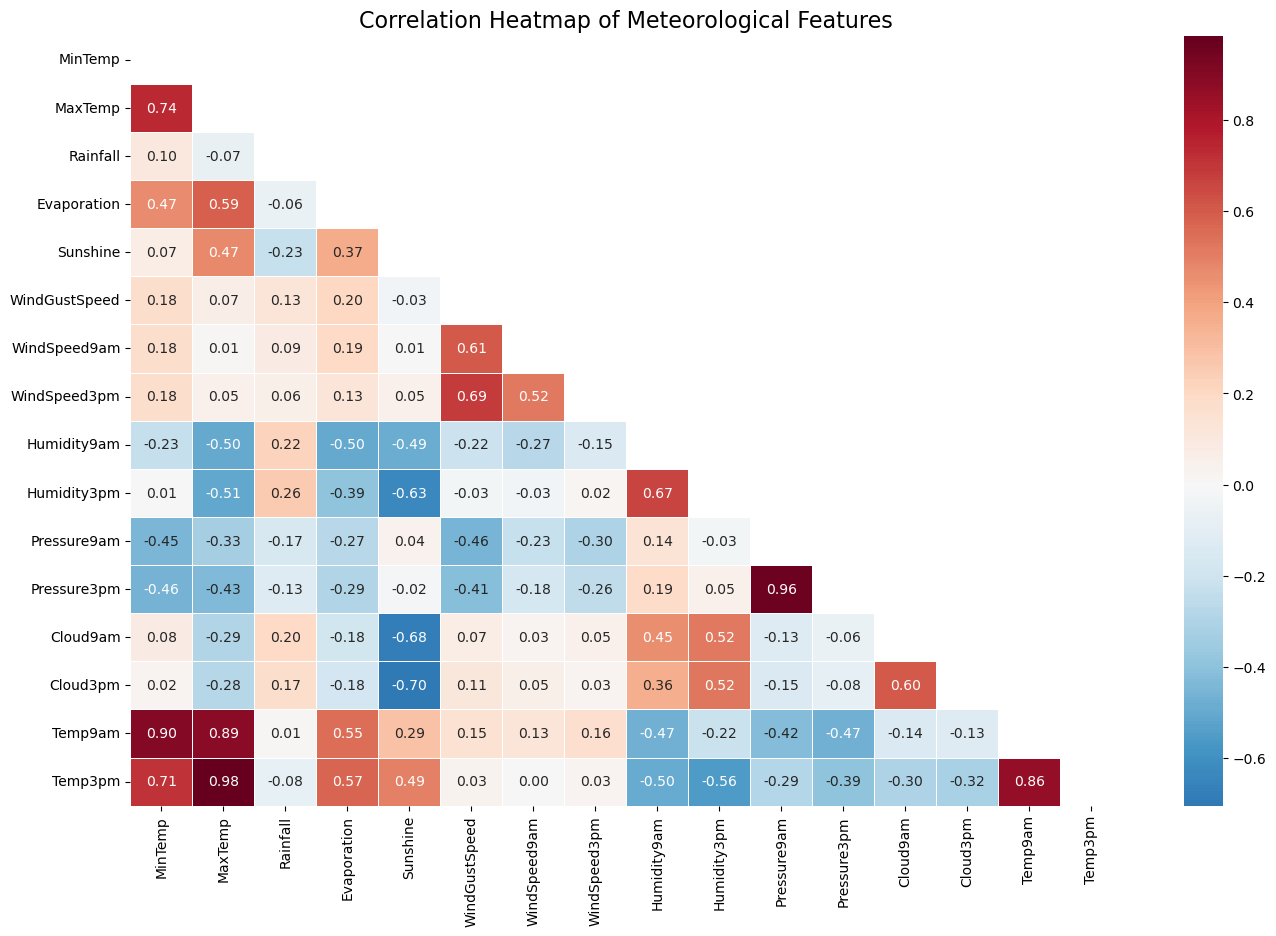

In [32]:
correlation_matrix_heatmap(df_weather)

Ma trận tương quan Pearson này giúp chúng ta định lượng mối quan hệ tuyến tính giữa các biến số. Từ Heatmap, nhóm chia các biến thành các "cụm thông tin" (information clusters) có tác động qua lại mạnh mẽ.

#### **7.1.1. Cụm Đa cộng tuyến cực mạnh (High Multicollinearity)**
Đây là các nhóm biến chứa thông tin gần như trùng lặp, cần lưu ý khi xây dựng các mô hình nhạy cảm với đa cộng tuyến như Logistic Regression.
* Nhóm Nhiệt độ (`MinTemp`, `MaxTemp`, `Temp9am`, `Temp3pm`):
  * Các biến này có hệ số tương quan thuận từ 0.70 đến 0.98.
  * Đáng chú ý nằm ở 2 biến `MaxTemp` và `Temp3pm` có tương quan gần như tuyệt đối ($\approx 0.98$). Điều này hợp lý vì nhiệt độ cao nhất trong ngày thường rơi vào khoảng xế chiều.
  * Nhóm hướng đến việc xử lí bằng cách trong các bước Feature Selection, chỉ cần giữ lại `MaxTemp` hoặc tính toán biến `TempRange = MaxTemp - MinTemp` để nắm bắt sự biến động nhiệt độ thay vì dùng cả 4 biến.
* Nhóm Áp suất (`Pressure9am`, `Pressure3pm`):
  * Có hệ số tương quan thuận cực mạnh (0.96). Điều này cho thấy áp suất khí quyển thường thay đổi rất chậm trong ngày.
  * Hướng xử lí: Có thể sử dụng giá trị trung bình hoặc chỉ giữ lại một biến vì chúng cung cấp thông tin dự báo tương đương nhau.

#### **7.1.2. Mối quan hệ nghịch biến giữa Sunshine, Cloud và Humidity**
Đây là nhóm biến chứa thông tin quan trọng để dự báo khả năng có mưa.
* **Sunshine với Cloud3pm/Cloud9am**:
  * Hệ số tương quan nghịch mạnh (khoảng -0.67 đến -0.71).
  * Lý do là vì lượng mây che phủ càng lớn thì số giờ nắng càng thấp. Mối quan hệ này rất chặt chẽ và nhất quán, cho thấy độ tin cậy của dữ liệu thu thập.
* **Sunshine với Humidity3pm**:
  * Hệ số tương quan nghịch khoảng -0.62.
  * Nhận xét: Khi độ ẩm buổi chiều cao, thường đi kèm với việc hình thành mây, dẫn đến giảm số giờ nắng. Đây là dấu hiệu tiền đề của các cơn mưa vào ngày hôm sau.

#### **7.1.3. Sự khác biệt giữa các mốc thời gian (9am và 3pm)**
* **Humidity**: `Humidity3pm` thường có tương quan với khả năng mưa cao hơn so với `Humidity9am`.
* **Wind Speed**: `WindGustSpeed` (tốc độ gió giật cao nhất) có tương quan thuận với cả `WindSpeed9am` và `WindSpeed3pm`, nhưng thường mạnh hơn ở mốc 3pm. Điều này gợi ý rằng các biến số đo lường vào buổi chiều mang nhiều tín hiệu dự báo cho ngày mai hơn là các biến buổi sáng.

#### **7.1.4. Những mối tương quan yếu gây bất ngờ**
* **Rainfall với các biến khác**: Lượng mưa của ngày hôm nay (`Rainfall`) có tương quan khá thấp ($< 0.3$) với các biến số khác như Áp suất hay Nhiệt độ. Điều này có thể lí giải bởi trường hợp mưa là một hiện tượng phi tuyến tính phức tạp. Việc hôm nay mưa bao nhiêu không phụ thuộc tuyến tính đơn giản vào việc hôm nay nóng bao nhiêu. Điều này cho thấy việc sử dụng các mô hình học máy phi tuyến (như Random Forest hoặc XGBoost) sẽ hiệu quả hơn các mô hình tuyến tính đơn giản.
* **WindGustSpeed với Pressure**: Có hệ số tương quan nghịch nhẹ, cho thấy rằng khi áp suất giảm đột ngột (rãnh thấp), tốc độ gió thường có xu hướng tăng lên.

## **8. Outlier Detection** 

*(Bao gồm: Sử dụng phương pháp IQR hoặc Z-score trên các biến quan trọng. Giải thích nguyên nhân xuất hiện ngoại lai (do lỗi cảm biến hay do thực tế sử dụng) và đề xuất hướng xử lý: giữ nguyên, cắt xén (clipping), hoặc loại bỏ).*

## **9. Data Preprocessing & Feature Engineering**

### **9.1 Missing Data**

Phân tích dữ liệu thiếu (missing data) là bước then chốt để đánh giá độ tin cậy của bộ dữ liệu. Mục tiêu của phần này không chỉ là định lượng tỷ lệ thiếu, mà quan trọng hơn là xác định Cơ chế gây thiếu (Missingness Mechanism). Việc xác định dữ liệu thiếu ngẫu nhiên (MCAR) hay có hệ thống (MNAR) sẽ quyết định chiến lược xử lý (Imputation Strategy), đảm bảo không làm sai lệch tính chất vật lý của dữ liệu khí tượng.

#### **Missing Summary Table**

Chúng ta bắt đầu bằng cái nhìn tổng quan định lượng về tỷ lệ thiếu của từng biến số.

In [14]:
def compute_missing_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute missing value statistics for each feature in the DataFrame.
    Returns a summary table sorted by missing percentage.
    """

    num_rows = df.shape[0]
    summary = []
    for col_name in df.columns:
        col = df[col_name]
        missing_count = col.isna().sum()
        if col.dtype == "object" or col.dtype.name == "category":
            missing_count += (col.astype(str).str.strip() == "").sum()
        missing_percent = (missing_count / num_rows) * 100
        summary.append([col_name, missing_count, missing_percent])
    missing_df = pd.DataFrame(
        summary,
        columns=["Feature", "Missing Count", "Missing %"]
    )
    missing_df = (
        missing_df.sort_values("Missing %", ascending=False)
                  .reset_index(drop=True)
    )
    return missing_df

In [15]:
missing_df = compute_missing_table(df_weather)
total_cells = df_weather.size
total_missing = missing_df["Missing Count"].sum()
overall_missing_rate = (total_missing / total_cells) * 100

print("Dataset Missing Overview:")
print(f"- Total Missing Values    : {total_missing:,.0f}")
print(f"- Overall Missing Rate    : {overall_missing_rate:.2f}%")
print(f"- Columns With Missing    : {missing_df.shape[0]} / {df_weather.shape[1]}\n")
print("Detailed Missingness by Feature (Descending):")
display(
    missing_df.style
        .format({"Missing %": "{:.2f}%"})
        .bar(subset=["Missing %"], color="#FF6B6B")
        .background_gradient(subset=["Missing Count"], cmap="Reds")
)

Dataset Missing Overview:
- Total Missing Values    : 343,248
- Overall Missing Rate    : 10.26%
- Columns With Missing    : 23 / 23

Detailed Missingness by Feature (Descending):


,Feature,Missing Count,Missing %
0,Sunshine,69835,48.01%
1,Evaporation,62790,43.17%
2,Cloud3pm,59358,40.81%
3,Cloud9am,55888,38.42%
4,Pressure9am,15065,10.36%
5,Pressure3pm,15028,10.33%
6,WindDir9am,10566,7.26%
7,WindGustDir,10326,7.10%
8,WindGustSpeed,10263,7.06%
9,Humidity3pm,4507,3.10%


**Nhận xét về kết quả**

Kết quả thống kê cho thấy sự phân hóa rõ rệt về chất lượng dữ liệu giữa các nhóm biến, cho thấy tính không đồng nhất về năng lực quan trắc giữa các trạm:

**Nhóm "Nguy cơ cao" (> 35%):** là các biến phụ thuộc nhiều vào điều kiện thời tiết hoặc yêu cầu thiết bị chuyên dụng, chẳng hạn như `Evaporation` và `Sunshine`, có tỷ lệ thiếu lần lượt $\approx$43% và 48%. Hai biến phản ánh mức độ mây che phủ (`Cloud9am`, `Cloud3pm`) cũng cho thấy mức độ thiếu cao khoảng 38 – 41%, gợi ý rằng đây không phải là lỗi ngẫu nhiên, mà là Structural Missingness (Thiếu có cấu trúc). Rất nhiều trạm đo trong mạng lưới có thể không được trang bị cảm biến đo nắng hoặc bốc hơi (thường đắt tiền hoặc khó bảo trì hơn cảm biến nhiệt).

**Nhóm "Cần xử lý thận trọng" (5% - 15%):** Các biến `Pressure` và `WindGust` thiếu khoảng 10%. Đây là tỷ lệ đủ lớn để ảnh hưởng đến mô hình nếu xóa bỏ, do đó cần các phương pháp điền khuyết (imputation) dựa trên tương quan.

**Nhóm "Tin cậy" (< 5%):**  Các trường thông tin định danh như `Date` và `Location` có mức độ đầy đủ tuyệt đối (0%), phản ánh tính nhất quán của hệ thống ghi nhận ngày và vị trí đo. Các biến đo đạc thường xuyên như nhiệt độ (`Temp`), độ ẩm (`Humidity`) và tốc độ gió chỉ thiếu ở mức rất thấp (0.8% – 3%), cho thấy độ tin cậy cao của các thiết bị quan trắc tự động. Việc biến mục tiêu `RainTomorrow` chỉ thiếu $\approx$2.2% là một tín hiệu tích cực cho bài toán Supervised Learning.

**Tóm tắt kết quả**

| Nhóm biến                                         | Tỷ lệ thiếu | Nhận xét                                                     |
| ------------------------------------------------- | ----------- | ------------------------------------------------------------ |
| **Date, Location**                                | 0%          | Thông tin đầy đủ, ghi nhận nhất quán.                        |
| **Nhiệt độ, độ ẩm, tốc độ gió**                   | 0.8%–3%     | Dữ liệu quan trắc ổn định và ít bị thiếu.                    |
| **Lượng mưa (Rainfall, RainToday, RainTomorrow)** | $\approx$2.2%       | Mức thiếu thấp, thông tin tin cậy.                           |
| **Áp suất khí quyển (Pressure9am, Pressure3pm)**  | $\approx$10.3%      | Thiếu ở mức trung bình, cần xử lý.                           |
| **Độ che mây (Cloud9am, Cloud3pm)**               | 38 – 41%      | Quan sát không đều hoặc phụ thuộc ghi chép chủ quan.         |
| **Bốc hơi và nắng (Evaporation, Sunshine)**       | 43 – 48%      | Thiếu rất nhiều; chỉ một số trạm có thiết bị đo chuyên dụng. |

#### **Missing Pattern Visualization**

Để kiểm chứng giả thuyết về "Structural Missingness", ta sử dụng các biểu đồ trực quan để xem xét sự phân bố không gian và sự tương quan của các giá trị thiếu.

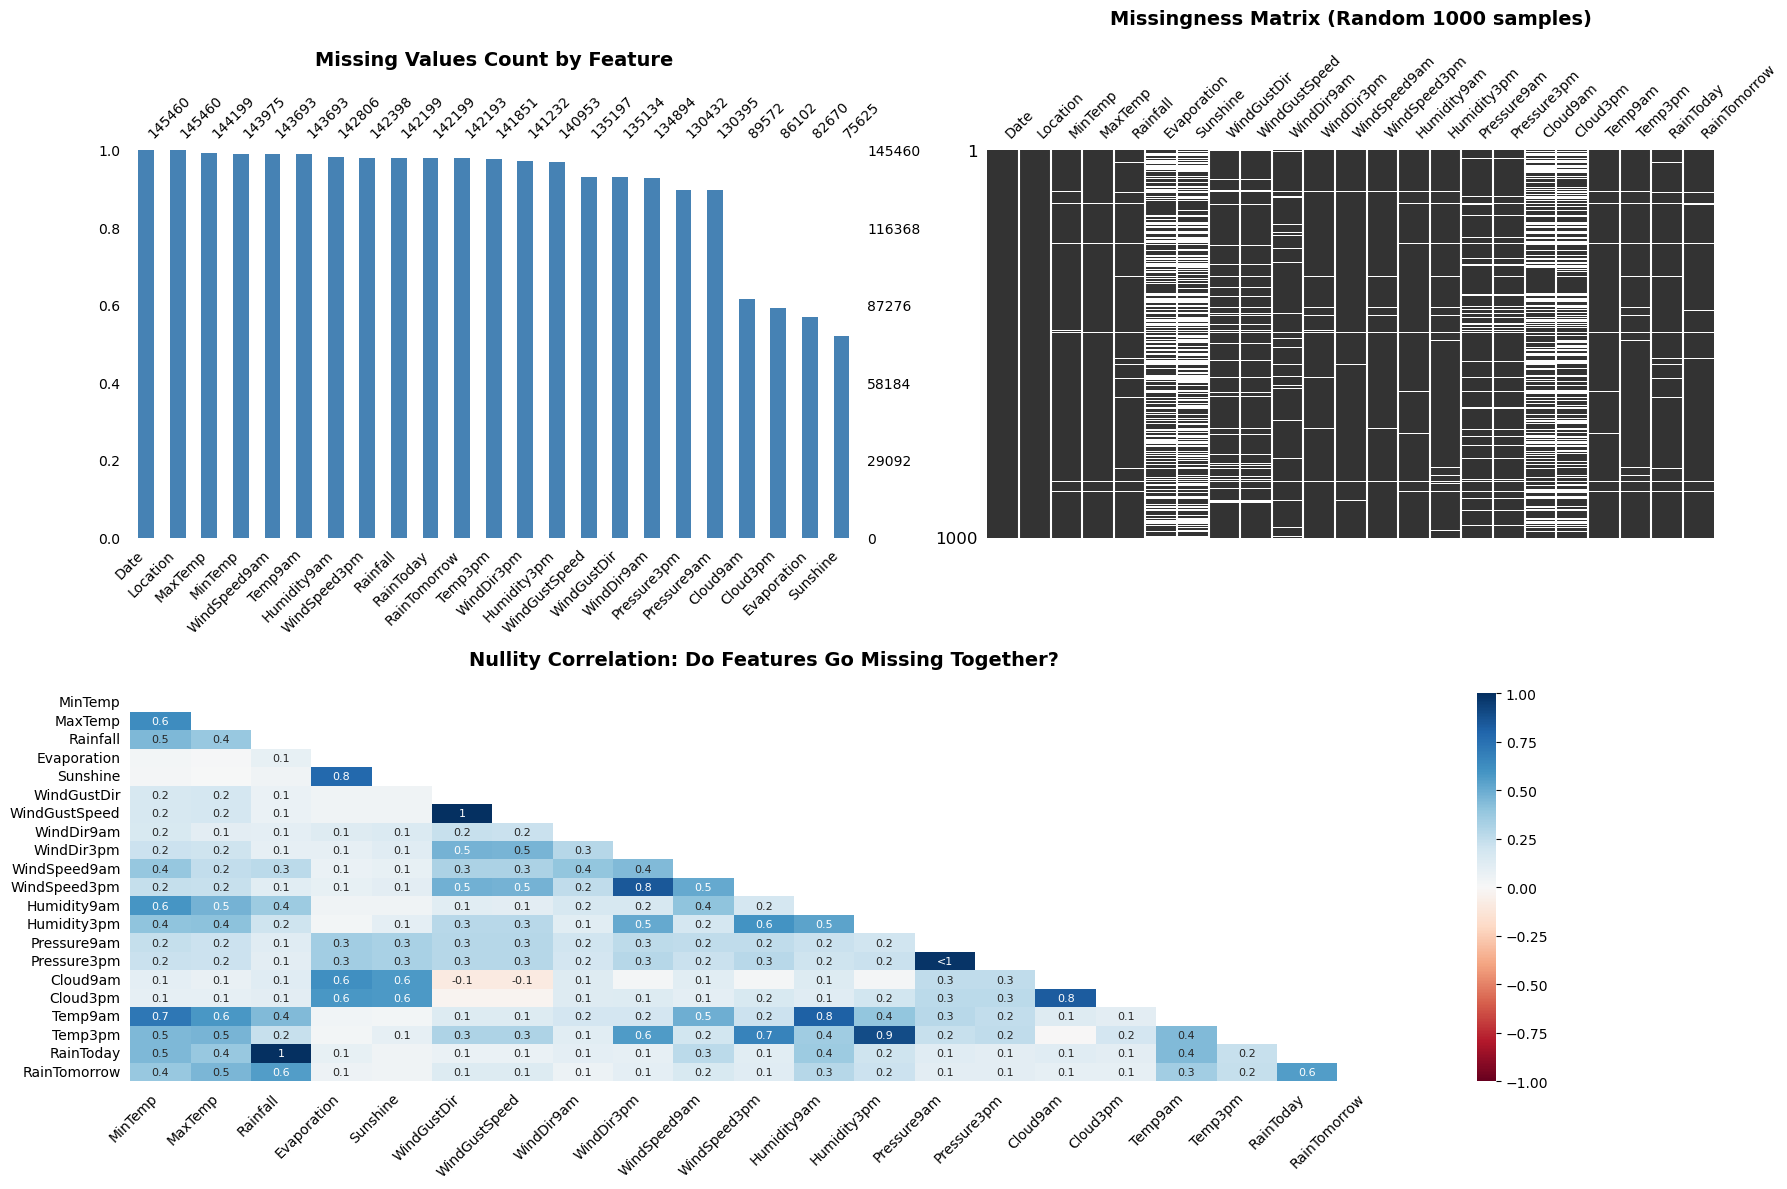

In [16]:
plot_missing_patterns(df_weather)

Trực quan hóa cấu trúc dữ liệu thiếu cho thấy các đặc điểm thiếu mang tính hệ thống thay vì ngẫu nhiên. 

**Biểu đồ cột cho thấy sự phân tầng rõ rệt giữa các nhóm biến**: các biến khí tượng cốt lõi (`Temperature`, `Humidity`, `WindSpeed`) có mức độ hoàn thiện gần như tuyệt đối, trong khi các biến phụ thuộc thiết bị chuyên dụng như `Evaporation`, `Sunshine`, `Cloud9am` và `Cloud3pm` lại thiếu dữ liệu ở mức cao, phản ánh sự không đồng nhất trong năng lực đo đạc giữa các trạm quan trắc.

**Biểu đồ ma trận làm rõ tính chất "structural missingness"**. Các khoảng trắng (đại diện cho dữ liệu thiếu) của `Evaporation` và `Sunshine` tập trung thành các khối liên tục theo thời gian, thay vì phân bố ngẫu nhiên, cho thấy khả năng một số trạm không được trang bị cảm biến tương ứng hoặc thiết bị ngừng hoạt động trong thời gian kéo dài. Điều này củng cố luận điểm rằng dữ liệu thiếu có tính hệ thống và liên quan đến đặc điểm của từng trạm.


**Biểu đồ heatmap tương quan nullity cho thấy sự phụ thuộc mạnh giữa các nhóm biến**. Các biến bốc hơi và bức xạ mặt trời (`Evaporation – Sunshine`) có tương quan thiếu cao, tương tự như cặp biến đo mây (`Cloud9am – Cloud3pm`) và cặp biến áp suất (`Pressure9am – Pressure3pm`). Các cặp này thường biến mất đồng thời, chỉ ra khả năng thiếu hụt liên quan đến cùng loại thiết bị hoặc điều kiện vận hành. Hiện tượng này chỉ ra rằng nếu một trạm thiếu thông tin về bốc hơi, xác suất rất cao trạm đó cũng không đo được giờ nắng, tương tự với việc quan sát mây.

$\rightarrow$ **Kết luận:** Cơ chế thiếu dữ liệu không phải là ngẫu nhiên hoàn toàn mà dữ liệu có dấu hiệu phụ thuộc vào định danh trạm đo.

#### **Proposed Treatment Strategy**

Chiến lược xử lý được đề xuất dựa trên mục tiêu mô hình hóa (classification RainTomorrow) và cơ chế missing:

##### **1. Nguyên tắc đối với giá trị ngoại lai (Outliers)**
- **Chiến lược:** **Giữ nguyên toàn bộ Outliers**, tuyệt đối không áp dụng Clipping (Cắt) hay Winsorization.
- **Lý do:** Các giá trị cực đoan trong nhiệt độ, gió và lượng mưa không phải lỗi đo đạc mà là các hiện tượng thời tiết đặc biệt (bão, hạn hán). Việc giữ lại giúp mô hình học được toàn bộ phổ biến thiên và các trạng thái khí quyển hiếm nhưng quan trọng cho dự báo mưa.


##### **2. Xử lý biến mục tiêu và biến phân loại**
- **RainTomorrow (Mục tiêu):** Loại bỏ các dòng bị thiếu (Drop NA) để đảm bảo độ chính xác cho nhãn huấn luyện.
- **RainToday:** Mã hóa Yes/No thành 1/0. Các giá trị thiếu được điền bằng mã riêng (**giá trị 2**) để đại diện cho trạng thái "Không xác định".
- **Biến phân loại khác (Vị trí, hướng gió):** Sử dụng Mode Imputation (Giá trị phổ biến nhất).

##### **3. Xử lý biến số liên tục (Numeric Imputation)**
Đây là nhóm đòi hỏi chiến lược thận trọng nhất để tránh làm mất thông tin vật lý:

| Nhóm biến | Tình trạng | Chiến lược xử lý |
| :--- | :--- | :--- |
| **Nhóm có tỷ lệ thiếu cao** (Evaporation, Sunshine, Cloud) | Thiếu nhiều, dữ liệu có ý nghĩa vật lý quan trọng. | **Missing Indicator Flags:** Tạo thêm cột nhị phân để đánh dấu vị trí bị thiếu, giúp mô hình nhận biết trạng thái "không quan trắc được". |
| **Toàn bộ biến số** (Nhiệt độ, Áp suất, Độ ẩm,...) | Cần tính nhất quán giữa các chỉ số. | **Iterative Imputer (MICE):** Tuyệt đối tránh Mean Imputation. Sử dụng MICE để dự đoán giá trị thiếu dựa trên các biến tương quan mạnh (ví dụ: dùng Nhiệt độ và Áp suất để dự đoán Độ ẩm). |


#### **4. Hàm ý vật lý của chiến lược**
Việc kết hợp giữa **MICE** và **Missing Indicator Flags** cho phép mô hình:
1. Có đủ dữ liệu liên tục để thực hiện các phép toán.
2. Hiểu được mối quan hệ phi tuyến giữa các biến (như gió mạnh và khả năng mưa).
3. Không bị sai lệch do việc điền các giá trị trung bình "ảo" vào các nhóm biến nhạy cảm như Sunshine hay Evaporation.

### **9.2 Data Splitting Strategy**

*(Thực hiện chia tách thành Train / Validation / Test với tỷ lệ 70% / 10% / 20%. 
**Lưu ý quan trọng trong đồ án:** Do bản chất `df_energy` là chuỗi thời gian, tuyệt đối KHÔNG xáo trộn ngẫu nhiên (`shuffle=False`). Phải cắt dữ liệu theo thứ tự thời gian tuyến tính để đảm bảo mô hình học từ quá khứ và dự báo tương lai).*

### **9.3 Feature Scaling**

*(Lựa chọn giữa `StandardScaler` (Z-score) hoặc `MinMaxScaler`. 
**Giải thích lý do:** Vì các biến như `Press_mm_hg` có giá trị lên tới ~750, trong khi `Windspeed` chỉ loanh quanh 1-10. Nếu không chuẩn hóa, thuật toán Gradient Descent sẽ hội tụ rất chậm hoặc các thuật toán tính khoảng cách (KNN, SVM) sẽ bị thiên lệch nặng.
**Biện pháp chống rò rỉ:** Chỉ gọi hàm `.fit()` trên tập Train, sau đó dùng `.transform()` cho cả 3 tập Train, Validation và Test).*